In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [2]:
# Load your dataset
data = pd.read_csv("augmented_hand_landmarks.csv")

# Extract features (landmark coordinates) and labels
X = data.drop(columns=['label']).values  # Only coordinates
y = data['label'].values  # Labels

# Generate pairs (This example assumes binary labels for simplicity, modify as per your dataset)

def create_pairs(X, y):
    pairs = []
    labels = []
    unique_labels = np.unique(y)
    label_to_indices = {label: np.where(y == label)[0] for label in unique_labels}
    
    for label in unique_labels:
        indices = label_to_indices[label]
        num_indices = len(indices)
        
        # Positive pairs
        for i in range(num_indices):
            # Randomly select another sample from the same class
            j = np.random.choice(indices)
            pairs.append([X[indices[i]], X[j]])
            labels.append(1)  # Similar pair
        
        # Negative pairs
        for i in range(num_indices):
            # Select a different label
            different_label = np.random.choice(unique_labels[unique_labels != label])
            neg_index = np.random.choice(label_to_indices[different_label])
            pairs.append([X[indices[i]], X[neg_index]])
            labels.append(0)  # Dissimilar pair
    
    return np.array(pairs), np.array(labels)

pairs, labels = create_pairs(X, y)
pairs_train, pairs_test, labels_train, labels_test = train_test_split(pairs, labels, test_size=0.2, random_state=42)


In [3]:
from tensorflow.keras import layers, Model

def build_base_network(input_shape):
    input = layers.Input(shape=input_shape)
    
    # First dense layer with increased width
    x = layers.Dense(256, activation=None, kernel_initializer='he_normal')(input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)  # Apply ReLU after Batch Normalization
   
    # Second dense layer
    x = layers.Dense(128, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Third dense layer
    x = layers.Dense(128, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Fourth dense layer
    x = layers.Dense(64, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Fifth dense layer
    x = layers.Dense(256, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Final embedding layer with 128 dimensions (no activation)
    x = layers.Dense(128, activation=None)(x)
    
    return Model(input, x)

input_shape = pairs_train.shape[2:]

base_network = build_base_network(input_shape)

# Inputs for the pairs
input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

# Generate the embeddings for each input
embedding_a = base_network(input_a)
embedding_b = base_network(input_b)

# Compute the L2 distance between embeddings
distance = layers.Lambda(lambda embeddings: tf.reduce_sum(tf.square(embeddings[0] - embeddings[1]), axis=-1))([embedding_a, embedding_b])

# Siamese Network model
siamese_model = Model(inputs=[input_a, input_b], outputs=distance)


In [14]:
# Contrastive loss
def contrastive_loss(y_true, y_pred, margin=1.0):
    y_true = tf.cast(y_true, y_pred.dtype)
    positive_loss = y_true * tf.square(y_pred)
    negative_loss = (1 - y_true) * tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(positive_loss + negative_loss)

# Custom accuracy
def accuracy(y_true, y_pred, threshold=1.0):
    print(f"{y_pred} < {threshold}")
    y_pred_labels = tf.cast(y_pred < threshold, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred_labels), tf.float32))

siamese_model.compile(optimizer='adam', loss=contrastive_loss, metrics=[accuracy])


In [15]:
history = siamese_model.fit(
    [pairs_train[:, 0], pairs_train[:, 1]], labels_train,
    validation_data=([pairs_test[:, 0], pairs_test[:, 1]], labels_test),
    batch_size=32,
    epochs=20
)


Epoch 1/20
Tensor("model_1/lambda/Sum:0", shape=(32,), dtype=float32) < 1.0
Tensor("model_1/lambda/Sum:0", shape=(32,), dtype=float32) < 1.0
 2229/36582 [>.............................] - ETA: 43s - loss: 8.7378e-04 - accuracy: 0.9912

KeyboardInterrupt: 

In [6]:
# Evaluate on test data
test_loss, test_acc = siamese_model.evaluate([pairs_test[:, 0], pairs_test[:, 1]], labels_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

9146/9146 [==============================] - 6s 705us/step - loss: 4.8635e-04 - accuracy: 0.9945
Test Loss: 0.0005, Test Accuracy: 0.9945


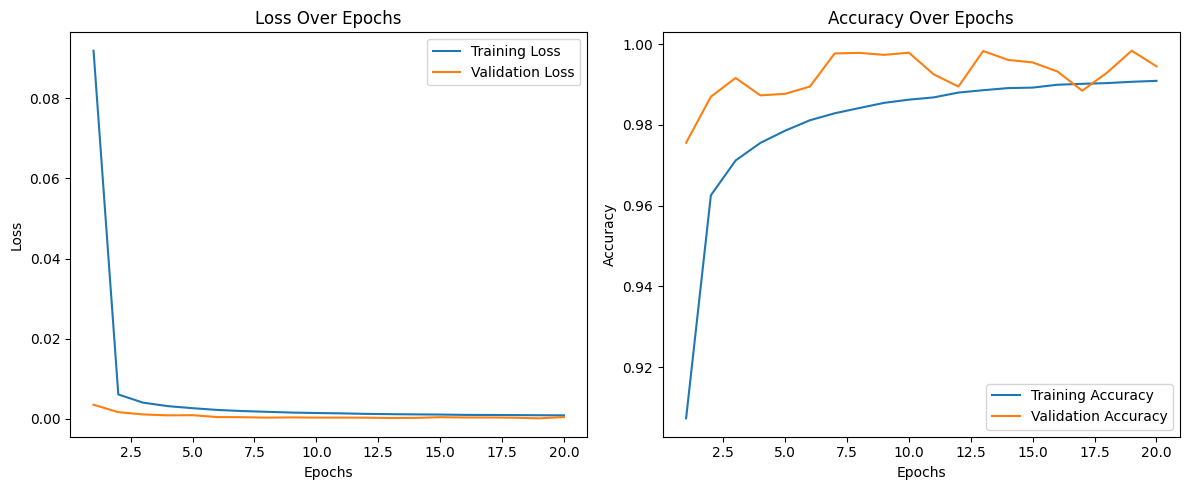

In [7]:
# Plot training/validation loss and accuracy
def plot_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Loss plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [16]:
# Extract embeddings
def get_embeddings(base_network, X):
    return base_network.predict(X)

# Convert string labels to numeric labels
def map_labels_to_numbers(labels):
    unique_labels = sorted(np.unique(labels))
    label_to_num = {label: idx for idx, label in enumerate(unique_labels)}
    numeric_labels = np.array([label_to_num[label] for label in labels])
    return numeric_labels, label_to_num

# Perform t-SNE and plot
def plot_tsne(embeddings, labels, label_names=None, title="t-SNE Visualization"):
    # Map labels to numeric
    numeric_labels, label_to_num = map_labels_to_numbers(labels)
    
    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=numeric_labels, cmap='tab10', alpha=0.7)
    
    if label_names:
        # Reverse map for legend
        num_to_label = {v: k for k, v in label_to_num.items()}
        legend_labels = [num_to_label[num] for num in np.unique(numeric_labels)]
        legend = plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, loc="best", fontsize=10)
        plt.gca().add_artist(legend)
    
    plt.title(title)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage
# Assuming you already have your data (X, y) and trained `base_network`
embeddings = get_embeddings(base_network, X)

# Optional: Provide class names if available
class_names = [chr(i) for i in range(ord('A'), ord('Z') + 1)] + ["Blank"]

# Plot embeddings using t-SNE
plot_tsne(embeddings, y, label_names=class_names, title="t-SNE Visualization of Hand Embeddings")

22864/22864 [==============================] - 15s 670us/step


KeyboardInterrupt: 

In [8]:
base_network.save("embedding_model_aug.h5")
print("Base embedding model saved as embedding_model_aug.h5")

Base embedding model saved as embedding_model_aug.h5


c:\Users\Elvis\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [9]:
import json
import numpy as np

def compute_class_means(model, X, y, classes):
    """Compute mean embeddings for each class."""
    class_means = {}
    for cls in classes:
        indices = np.where(y == cls)[0]
        embeddings = model.predict(X[indices])
        class_means[cls] = np.mean(embeddings, axis=0).tolist()
    
    # Save class means to a JSON file
    with open("class_means_aug.json", "w") as f:
        json.dump(class_means, f)
    print("Class means saved to class_means_aug.json")

# Assuming X and y are your dataset and labels
classes = np.unique(y)
compute_class_means(base_network, X, y, classes)


802/802 [==============================] - 1s 679us/step
Class means saved to class_means_aug.json
